In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm, kurtosis
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

close = pd.read_parquet("close_prices.parquet")
daily_returns = pd.read_parquet("daily_returns.parquet")
annual_summary = pd.read_parquet("annual_summary.parquet")


In [3]:
mean_returns = daily_returns.mean()
volatility = daily_returns.std()

max_drawdowns = ((close / close.cummax()) - 1).min()

features = pd.DataFrame({"Mean Return": mean_returns, "Volatility": volatility, "Max Drawdown": max_drawdowns})
features.head()

,Mean Return,Volatility,Max Drawdown
Ticker,,,
AAPL,0.001088,0.017929,-0.385159
ABBV,0.000701,0.016792,-0.450898
ABT,0.000554,0.014859,-0.338767
ACN,0.000736,0.015675,-0.396878
ADBE,0.000942,0.020900,-0.600215


Create feautures (numbers) as input for the K means algorith in order to identify clusters.
Features are: Mean return, Volatilty, and Max Drawdowns.
Next stage add skew as feature.

(69, 3)


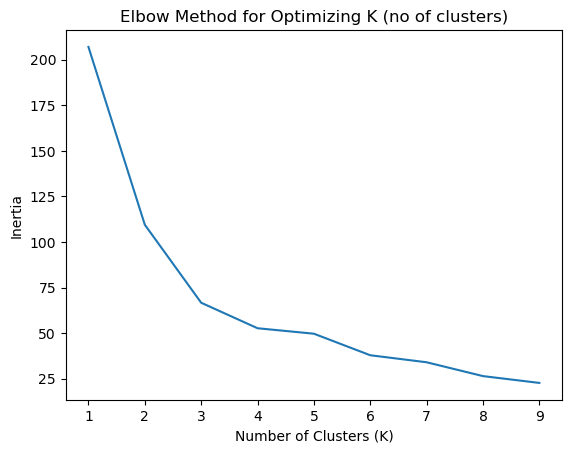

[207.0000000000001, 109.47601076717747, 66.68979937096194, 52.702599235958075, 49.70136728838709, 37.888917582108846, 34.037970447856296, 26.446831357638303, 22.71068018655189]


In [4]:
scaler = StandardScaler()
StandardScaler()
features = features.dropna()
features_scaled = scaler.fit_transform(features)
print(features_scaled.shape)

inertia = []
k_range = range(1,10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=5)
    clusters = kmeans.fit_predict(features_scaled)

    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertia)
plt.title("Elbow Method for Optimizing K (no of clusters)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

print(inertia)

For a chosen amount of clusters, KMeans algorithm tries to minimizes inertia (sqaured distance between points and their cluster center).

We can determine a suitable number of clusters for our features by trailing over numbers of cluster (1-10). Using the elbow method the desired number of clusters is found at the point where adding more clusters gives diminishing returns (minimizing inertia).

In this case there is a much smaller drop in inerita between 3-4 than there is 2-3, so we can use no of cluster = 3.

In [5]:
scaler = StandardScaler()
StandardScaler()
features = features.dropna()
features_2 = features.dropna()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=5)
clusters = kmeans.fit_predict(features_scaled)

features["cluster"] = clusters
features.head(15)

,Mean Return,Volatility,Max Drawdown,cluster
Ticker,,,,
AAPL,0.001088,0.017929,-0.385159,1
ABBV,0.000701,0.016792,-0.450898,1
ABT,0.000554,0.014859,-0.338767,1
ACN,0.000736,0.015675,-0.396878,1
ADBE,0.000942,0.020900,-0.600215,0
AMD,0.002184,0.036945,-0.654499,2
AMGN,0.000429,0.015610,-0.248600,1
AMZN,0.001268,0.020650,-0.561453,0
ANET,0.001684,0.026649,-0.522006,2


scaler - rescales data using its mean and standard deviation i.e. centers data around zero (using mean) and gives standard deviation in same order of magnitude. ML models work best when scaled like this.

Use K means algorithm to determine clusters of Companies.
Using n amount of clusters (=3) (...tbc)

In [6]:
features.groupby("cluster").mean()

,Mean Return,Volatility,Max Drawdown
cluster,,,
0,0.000683,0.020254,-0.570261
1,0.000681,0.015446,-0.371911
2,0.001950,0.030214,-0.636442


Stocks in the same cluster share similar features:  
Cluster 0 - High returns, medium volatility, large drawdowns   
Cluster 1 - High returns, low volatility, low volatility, low drawdowns  
Cluster 2 - Low returns, High volatility, large drawdowns

In [14]:
cluster_0 = features[features["cluster"] == 0]
cluster_1 = features[features["cluster"] == 1]
cluster_2 = features[features["cluster"] == 2]
cluster_0.head(22)
cluster_1.head(41)

,Mean Return,Volatility,Max Drawdown,cluster
Ticker,,,,
AAPL,0.001088,0.017929,-0.385159,1
ABBV,0.000701,0.016792,-0.450898,1
ABT,0.000554,0.014859,-0.338767,1
ACN,0.000736,0.015675,-0.396878,1
AMGN,0.000429,0.015610,-0.248600,1
BLK,0.000667,0.017134,-0.439017,1
CAT,0.000828,0.018749,-0.433589,1
COST,0.000919,0.013592,-0.314025,1
CSCO,0.000550,0.015766,-0.419511,1


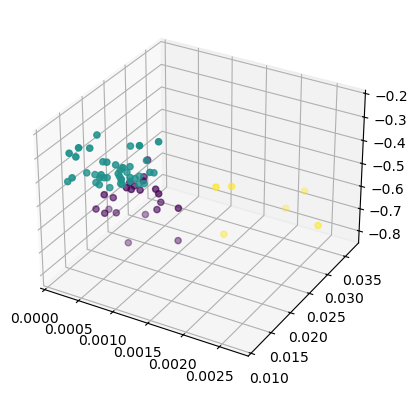

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    features["Mean Return"],
    features["Volatility"],
    features["Max Drawdown"],
    c=features["cluster"]
)

3D plot with clusters shown with colours, visualises feature space and how clusters share and occupy similar spaces.

Analysing this 3D plot 2 cluster groups may have been better so it is also included below

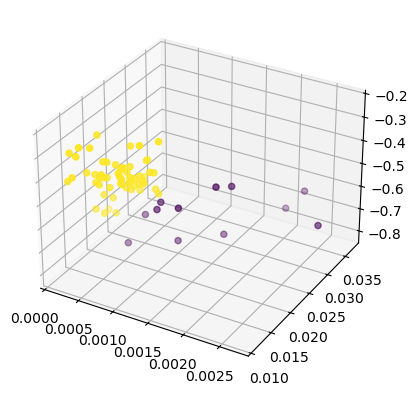

,Mean Return,Volatility,Max Drawdown
cluster,,,
0,0.001411,0.026224,-0.654365
1,0.000662,0.016587,-0.416848


In [9]:
features_2_scaled = scaler.fit_transform(features_2)
kmeans_2 = KMeans(n_clusters=2, random_state=5)
clusters_2 = kmeans_2.fit_predict(features_2_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
features_2["cluster"] = clusters_2

ax.scatter(
    features_2["Mean Return"],
    features_2["Volatility"],
    features_2["Max Drawdown"],
    c=features_2["cluster"]
)
plt.show()

features_2.groupby("cluster").mean()

The data set is now broken into 2 cluster groups:  
Cluster 1 - High Return, Medium volatility, Large Dragdown  
Cluster 2 - Low Return, Low Volatility, Medium Dragdown  